# House Price Prediction Using Linear Regression

## Objective

The objective of this project is to build a simple linear regression model
to predict house prices using the Boston Housing dataset.

The project includes:
- Loading and exploring the dataset
- Selecting features and target variable
- Splitting the data into training and testing sets
- Building a Linear Regression model
- Interpreting model coefficients
- Evaluating the model using R² and Mean Squared Error (MSE)
- Visualizing actual and predicted house prices

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Load the Excel file
raw_data = pd.read_excel("4) house Prediction Data Set.csv.xlsx", header=None)

# Split the space-separated values into separate columns
df = raw_data[0].str.split(expand=True)

# Convert all columns to numeric
df = df.astype(float)

# Display the first five rows
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [4]:
columns = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM",
    "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B",
    "LSTAT", "MEDV"
]

df.columns = columns

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [5]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]


In [6]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
df.info()

Dataset Shape: (506, 14)

Column Names:
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

Missing Values:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non

In [7]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

# Statistical summary
df.describe()

Number of duplicate rows: 0


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [8]:
print("Target Variable: MEDV")
print("Minimum house value:", df["MEDV"].min())
print("Maximum house value:", df["MEDV"].max())
print("Average house value:", df["MEDV"].mean())

Target Variable: MEDV
Minimum house value: 5.0
Maximum house value: 50.0
Average house value: 22.532806324110677


In [9]:
# Calculate correlations with the target variable
correlation = df.corr()["MEDV"].sort_values(ascending=False)

print(correlation)

MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


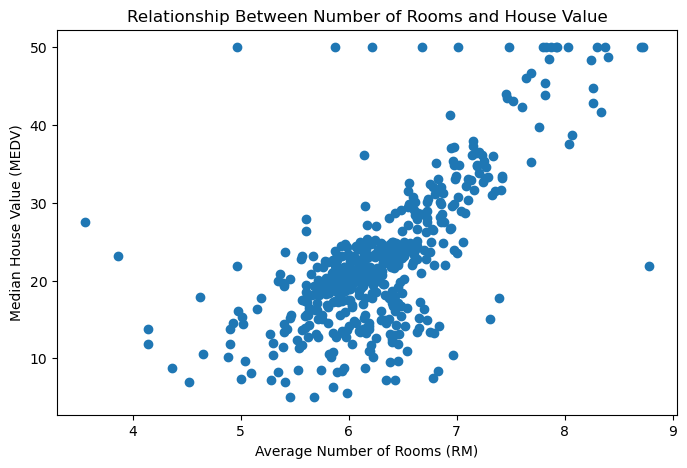

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(df["RM"], df["MEDV"])

plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Median House Value (MEDV)")
plt.title("Relationship Between Number of Rooms and House Value")

plt.show()

In [11]:
# Select feature and target variable
X = df[["RM"]]
y = df["MEDV"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (506, 1)
Target shape: (506,)


In [12]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 404
Testing samples: 102


In [13]:
# Create and train the Linear Regression model
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
# Display the model intercept and coefficient
print("Intercept:", model.intercept_)
print("Coefficient for RM:", model.coef_[0])

Intercept: -36.24631889813795
Coefficient for RM: 9.348301406497727


## Model Equation

The simple linear regression model is represented by:

**MEDV = -36.2463 + 9.3483 × RM**

Where:
- **MEDV** is the predicted median house value.
- **RM** is the average number of rooms per dwelling.
- **-36.2463** is the intercept.
- **9.3483** is the regression coefficient for RM.

In [15]:
# Make predictions on the test data
y_pred = model.predict(X_test)

# Display the first 10 predictions
print(y_pred[:10])

[23.73238293 26.92950201 19.68456842 20.45112913 22.61993506 22.45166563
 19.03953562 21.47009399 21.98425056 20.09589368]


In [16]:
# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R-squared (R²):", r2)

Mean Squared Error (MSE): 46.144775347317264
R-squared (R²): 0.3707569232254778


## Model Evaluation

The model was evaluated using Mean Squared Error (MSE) and R-squared (R²).

- **Mean Squared Error (MSE): 46.1448**
- **R-squared (R²): 0.3708**

The R² value indicates that approximately **37.1% of the variation in
median house values is explained by the average number of rooms alone.

The MSE represents the average squared difference between the actual and
predicted house values.

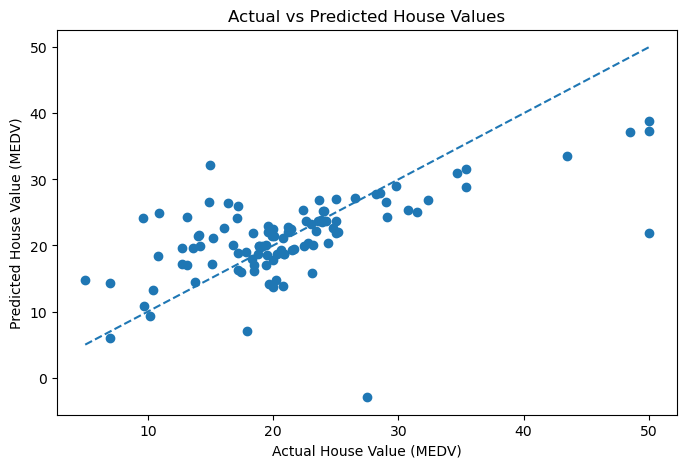

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Value (MEDV)")
plt.ylabel("Predicted House Value (MEDV)")
plt.title("Actual vs Predicted House Values")

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

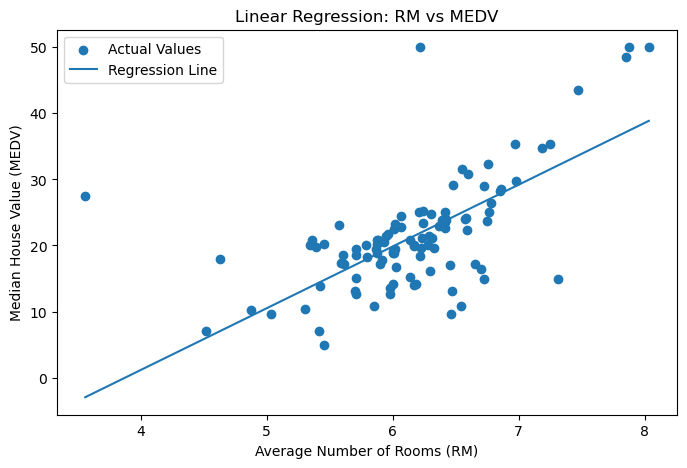

In [19]:

# Sort RM values for a smooth regression line
sorted_indices = X_test["RM"].argsort()

X_sorted = X_test["RM"].iloc[sorted_indices]
y_pred_sorted = y_pred[sorted_indices]

plt.figure(figsize=(8, 5))

plt.scatter(X_test["RM"], y_test, label="Actual Values")

plt.plot(
    X_sorted,
    y_pred_sorted,
    label="Regression Line"
)

plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Median House Value (MEDV)")
plt.title("Linear Regression: RM vs MEDV")
plt.legend()

plt.show()

## Key Observations

- The dataset contains **506 observations and 14 variables**.
- No missing values or duplicate rows were found.
- RM showed a strong positive correlation with MEDV (**0.6954**).
- The regression coefficient for RM is positive, confirming that house
  value generally increases as the number of rooms increases.
- The model achieved an R² of **0.3708** on the test data.
- The model's moderate R² shows that RM alone cannot fully explain house
  prices, as other housing and socioeconomic factors also influence value.

## Conclusion

A simple linear regression model was successfully developed to predict
median house values using the average number of rooms as the predictor.

The model demonstrated a positive relationship between the number of rooms
and house value, with an R² of 0.3708 and an MSE of 46.1448.

Although the model provides useful insight into the relationship between
RM and MEDV, its predictive ability is limited because house prices depend
on several factors. A multiple linear regression model using additional
features could potentially improve prediction performance.